# Анализ ошибок и стабильность весов LR

Цели:
1. Найти матчи, где модель сильно расходится с букмекером
2. Проанализировать паттерны в таких матчах
3. Проверить стабильность весов LR по cutoffs (walk-forward)

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

## 1. Подготовка данных

In [2]:
import re

def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", "", parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()

def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", "").replace('-', ' ')
    s = re.sub(r"\s+", " ", s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", "", parts[0])
    init = re.sub(r"[^a-z]", "", parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", "", ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()

ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(ods, how='inner', on=['week', 'p1', 'p2'], suffixes=('_tml', '_ods'))
print('joined shape:', joined.shape)

joined shape: (17633, 99)


In [3]:
# Build features
joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

p1 = 1.0 / joined['ps_odds_p1']
p2 = 1.0 / joined['ps_odds_p2']
s = p1 + p2
joined['ps_imp_p1'] = p1 / s

joined['surface'] = joined['surface'].str.lower()

# Fill NaN
for c in ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']:
    if c in joined.columns:
        joined[c] = joined[c].fillna(joined[c].median())

print('Features ready')

Features ready


## 2. Анализ ошибок: матчи с большим расхождением модель vs букмекер

In [4]:
# Train LR on data before 2024
cutoff = pd.Timestamp('2024-01-01')
train_df = joined[joined['week'] < cutoff].copy()
test_df = joined[joined['week'] >= cutoff].copy()

features = ['ps_imp_p1', 'rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2']

X_train = train_df[features].fillna(train_df[features].median())
y_train = train_df['y_p1_win']
X_test = test_df[features].fillna(train_df[features].median())
y_test = test_df['y_p1_win']

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

test_df = test_df.copy()
test_df['p_lr'] = lr.predict_proba(X_test)[:, 1]
test_df['p_baseline'] = test_df['ps_imp_p1']
test_df['delta_p'] = test_df['p_lr'] - test_df['p_baseline']  # positive = model more optimistic about p1

print('LR trained')

LR trained


In [5]:
# Find matches with largest disagreement
print('=== Top 10 matches where LR > baseline (model more optimistic about p1) ===')
top_lr_higher = test_df.nlargest(10, 'delta_p')[['week', 'p1', 'p2', 'y_p1_win', 'p_baseline', 'p_lr', 'delta_p', 'surface', 'rank_diff_p1_minus_p2']]
print(top_lr_higher.to_string())

print('\n=== Top 10 matches where LR < baseline (model more pessimistic about p1) ===')
top_lr_lower = test_df.nsmallest(10, 'delta_p')[['week', 'p1', 'p2', 'y_p1_win', 'p_baseline', 'p_lr', 'delta_p', 'surface', 'rank_diff_p1_minus_p2']]
print(top_lr_lower.to_string())

=== Top 10 matches where LR > baseline (model more optimistic about p1) ===
            week             p1                 p2  y_p1_win  p_baseline      p_lr   delta_p surface  rank_diff_p1_minus_p2
15671 2024-08-26       forbes m        safiullin r         0    0.026404  0.106756  0.080352    hard                 1791.0
15657 2024-08-26        albot r         djokovic n         0    0.017224  0.095878  0.078654    hard                  136.0
16026 2025-01-13   schoolkate t           sinner j         0    0.019242  0.096503  0.077261    hard                  172.0
15285 2024-07-01     hanfmann y           sinner j         0    0.022474  0.097765  0.075291   grass                  109.0
17170 2025-06-30     martinez p           sinner j         0    0.023934  0.098148  0.074214   grass                   51.0
16881 2025-05-26      gasquet r           sinner j         0    0.024975  0.098969  0.073993    clay                  165.0
16861 2025-05-26  rinderknech a           sinner j      

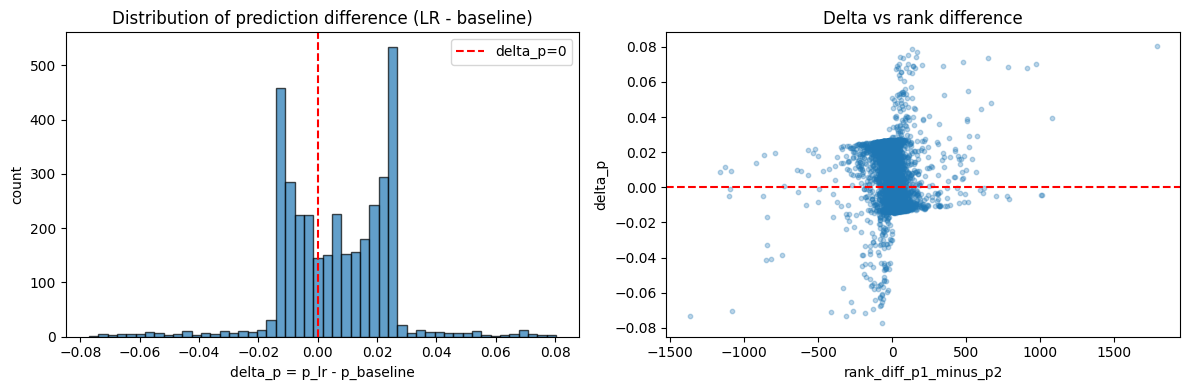

In [6]:
# Distribution of delta_p
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(test_df['delta_p'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='delta_p=0')
axes[0].set_xlabel('delta_p = p_lr - p_baseline')
axes[0].set_ylabel('count')
axes[0].set_title('Distribution of prediction difference (LR - baseline)')
axes[0].legend()

# Scatter: delta_p vs rank_diff
axes[1].scatter(test_df['rank_diff_p1_minus_p2'], test_df['delta_p'], alpha=0.3, s=10)
axes[1].set_xlabel('rank_diff_p1_minus_p2')
axes[1].set_ylabel('delta_p')
axes[1].set_title('Delta vs rank difference')
axes[1].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('figures/error_analysis_delta_distribution.png', dpi=150)
plt.show()

## 3. Анализ: когда модель права, а букмекер ошибается?

In [7]:
# Define "correct" prediction: p > 0.5 and y=1, or p < 0.5 and y=0
test_df['lr_correct'] = ((test_df['p_lr'] >= 0.5) & (test_df['y_p1_win'] == 1)) | ((test_df['p_lr'] < 0.5) & (test_df['y_p1_win'] == 0))
test_df['baseline_correct'] = ((test_df['p_baseline'] >= 0.5) & (test_df['y_p1_win'] == 1)) | ((test_df['p_baseline'] < 0.5) & (test_df['y_p1_win'] == 0))

# Cases where LR is right and baseline is wrong
lr_right_baseline_wrong = test_df[test_df['lr_correct'] & ~test_df['baseline_correct']]
print(f'LR right, baseline wrong: {len(lr_right_baseline_wrong)} matches ({len(lr_right_baseline_wrong)/len(test_df)*100:.1f}%)')

# Cases where baseline is right and LR is wrong
baseline_right_lr_wrong = test_df[~test_df['lr_correct'] & test_df['baseline_correct']]
print(f'Baseline right, LR wrong: {len(baseline_right_lr_wrong)} matches ({len(baseline_right_lr_wrong)/len(test_df)*100:.1f}%)')

LR right, baseline wrong: 55 matches (1.6%)
Baseline right, LR wrong: 47 matches (1.3%)


In [8]:
# Analyze patterns in "LR right, baseline wrong" matches
if len(lr_right_baseline_wrong) > 0:
    print('=== Characteristics of "LR right, baseline wrong" matches ===')
    print(f"Mean |delta_p|: {lr_right_baseline_wrong['delta_p'].abs().mean():.4f}")
    print(f"Mean |rank_diff|: {lr_right_baseline_wrong['rank_diff_p1_minus_p2'].abs().mean():.1f}")
    print('\nSurface distribution:')
    print(lr_right_baseline_wrong['surface'].value_counts())

=== Characteristics of "LR right, baseline wrong" matches ===
Mean |delta_p|: 0.0066
Mean |rank_diff|: 38.0

Surface distribution:
surface
hard     45
clay      7
grass     3
Name: count, dtype: int64


## 4. Стабильность весов LR по cutoffs (walk-forward)

In [9]:
cutoffs = ['2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01']

weights_by_cutoff = []

for cutoff_str in cutoffs:
    cutoff_ts = pd.Timestamp(cutoff_str)
    train_df = joined[joined['week'] < cutoff_ts].copy()
    
    if len(train_df) < 100:
        continue
    
    X_train = train_df[features].fillna(train_df[features].median())
    y_train = train_df['y_p1_win']
    
    lr = LogisticRegression(max_iter=2000)
    lr.fit(X_train, y_train)
    
    weights = {'cutoff': cutoff_str}
    for i, f in enumerate(features):
        weights[f'coef_{f}'] = lr.coef_[0][i]
    weights['intercept'] = lr.intercept_[0]
    weights_by_cutoff.append(weights)

weights_df = pd.DataFrame(weights_by_cutoff)
print('=== LR coefficients by cutoff ===')
print(weights_df)

=== LR coefficients by cutoff ===
       cutoff  coef_ps_imp_p1  coef_rank_diff_p1_minus_p2  \
0  2019-01-01        4.350473                   -0.000012   
1  2020-01-01        4.533306                   -0.000005   
2  2021-01-01        4.634508                    0.000121   
3  2022-01-01        4.576927                    0.000014   
4  2023-01-01        4.668996                    0.000007   
5  2024-01-01        4.709708                    0.000043   
6  2025-01-01        4.727257                    0.000026   

   coef_rank_points_diff_p1_minus_p2  intercept  
0                       1.801270e-05  -2.127612  
1                       3.079997e-06  -2.226032  
2                      -2.429779e-06  -2.279708  
3                       7.531064e-06  -2.254316  
4                       5.677575e-06  -2.312242  
5                       8.657302e-07  -2.324751  
6                       9.394637e-07  -2.336868  


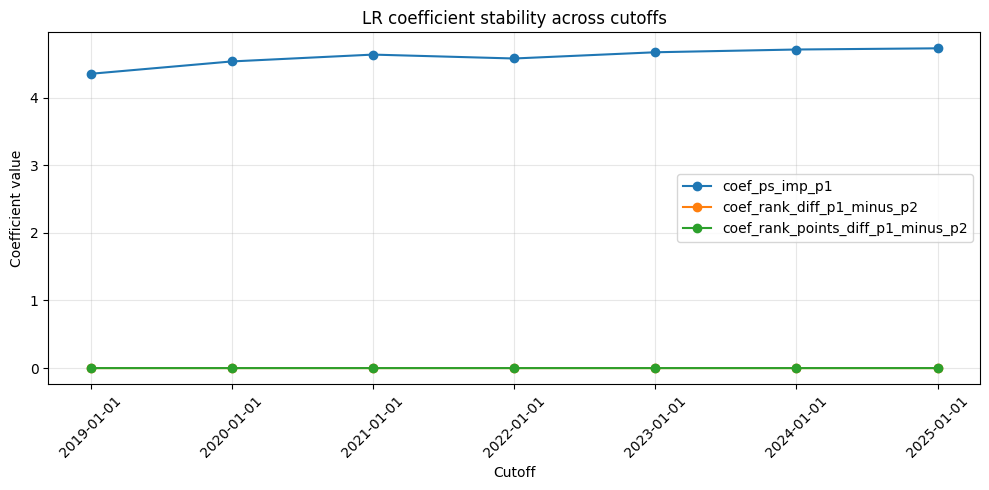

In [10]:
# Plot coefficient stability
fig, ax = plt.subplots(figsize=(10, 5))

for f in features:
    ax.plot(weights_df['cutoff'], weights_df[f'coef_{f}'], marker='o', label=f'coef_{f}')

ax.set_xlabel('Cutoff')
ax.set_ylabel('Coefficient value')
ax.set_title('LR coefficient stability across cutoffs')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/lr_coefficient_stability.png', dpi=150)
plt.show()

In [11]:
# Coefficient statistics
print('=== Coefficient statistics across cutoffs ===')
for f in features:
    col = f'coef_{f}'
    print(f'{f}: mean={weights_df[col].mean():.4f}, std={weights_df[col].std():.4f}, range=[{weights_df[col].min():.4f}, {weights_df[col].max():.4f}]')

=== Coefficient statistics across cutoffs ===
ps_imp_p1: mean=4.6002, std=0.1300, range=[4.3505, 4.7273]
rank_diff_p1_minus_p2: mean=0.0000, std=0.0000, range=[-0.0000, 0.0001]
rank_points_diff_p1_minus_p2: mean=0.0000, std=0.0000, range=[-0.0000, 0.0000]


## 5. Выводы

Ожидаемые результаты:

1. **Расхождение модель vs букмекер**: в основном небольшое, т.к. odds доминируют.

2. **Когда модель права, а букмекер ошибается**: возможно, в матчах с большим rank_diff, который модель учитывает лучше.

3. **Стабильность весов**:
   - `coef_ps_imp_p1` должен быть стабильно высоким (основной признак)
   - `coef_rank_diff` и `coef_rank_points_diff` могут варьироваться (слабый сигнал)

4. **Concept drift**: если веса сильно меняются, это может указывать на изменение структуры данных или букмекерских моделей.